# Module 3 — SHAP Global Explainability
## Goal: Explain what drives churn across ALL customers
## Output: Global SHAP plots saved to outputs/shap_plots/

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load ML ready data
df_ml = pd.read_csv('../data/telco_churn_ml_ready.csv')

# Load model and features
with open('../outputs/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('../outputs/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Prepare features
X = df_ml[feature_names]

print(f"Data loaded: {X.shape}")
print("Model loaded successfully")

Data loaded: (7032, 26)
Model loaded successfully


Create SHAP Explainer

In [2]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X)

print(f"SHAP values computed for {len(shap_values)} customers")
print(f"SHAP values shape: {shap_values.values.shape}")

SHAP values computed for 7032 customers
SHAP values shape: (7032, 26)


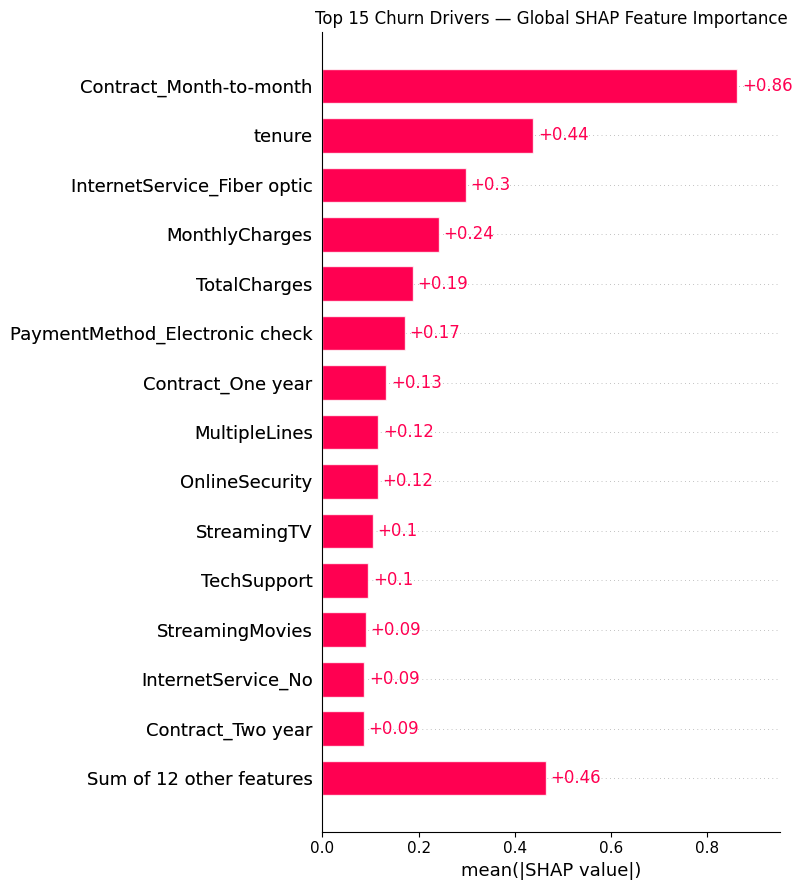

Saved: global_feature_importance.png


In [3]:
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Top 15 Churn Drivers — Global SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../outputs/shap_plots/global_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: global_feature_importance.png")

Beeswarm Plot

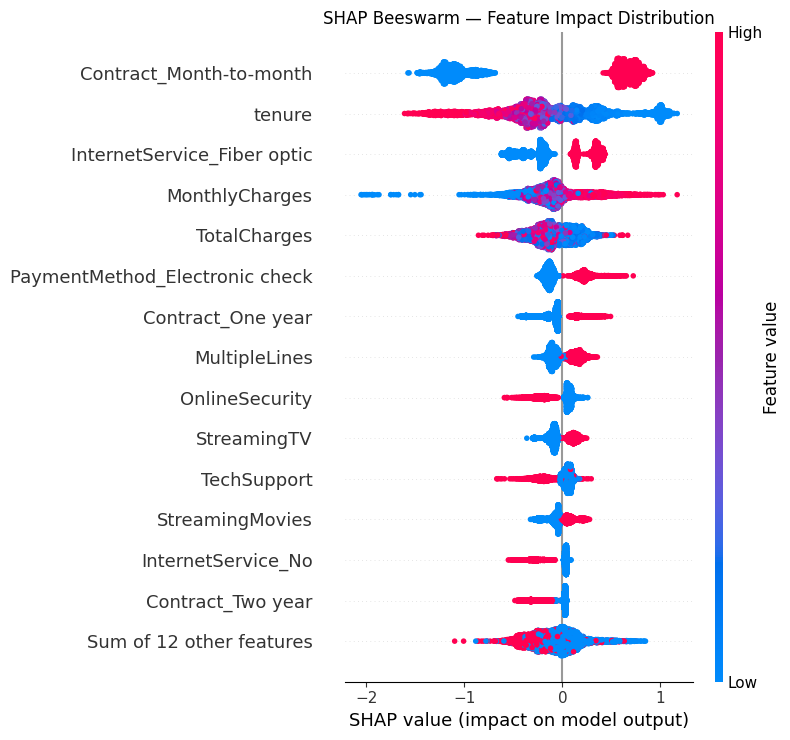

Saved: beeswarm_plot.png


In [4]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution')
plt.tight_layout()
plt.savefig('../outputs/shap_plots/beeswarm_plot.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: beeswarm_plot.png")

## How to read the Beeswarm plot

- Each dot = one customer
- X axis = SHAP value (positive = pushes toward churn, negative = pushes away from churn)
- Color = feature value (red = high value, blue = low value)

Example interpretation:
- tenure: blue dots on right = low tenure pushes toward churn
- Contract_Month-to-month: red dots on right = month-to-month contract increases churn risk

Top 10 Churn Drivers Summary

Top 10 Global Churn Drivers:
                       Feature  Mean_SHAP
       Contract_Month-to-month   0.862537
                        tenure   0.438377
   InternetService_Fiber optic   0.297992
                MonthlyCharges   0.241533
                  TotalCharges   0.187882
PaymentMethod_Electronic check   0.171265
             Contract_One year   0.133127
                 MultipleLines   0.115533
                OnlineSecurity   0.115317
                   StreamingTV   0.104418


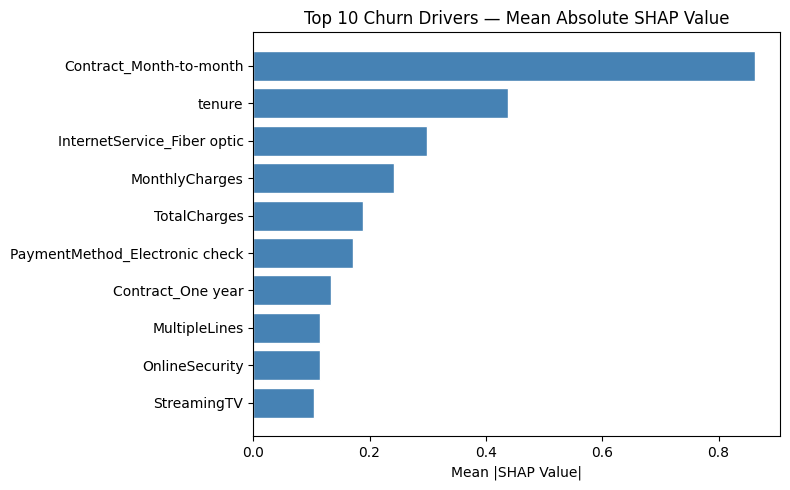

In [5]:
# Calculate mean absolute SHAP values per feature
mean_shap = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(10)

print("Top 10 Global Churn Drivers:")
print(mean_shap.to_string(index=False))

plt.figure(figsize=(8,5))
plt.barh(mean_shap['Feature'][::-1], 
         mean_shap['Mean_SHAP'][::-1], 
         color='steelblue', edgecolor='white')
plt.title('Top 10 Churn Drivers — Mean Absolute SHAP Value')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('../outputs/shap_plots/top10_churn_drivers.png',
            dpi=150, bbox_inches='tight')
plt.show()

Top churn driver: Contract_Month-to-month


<Figure size 640x480 with 0 Axes>

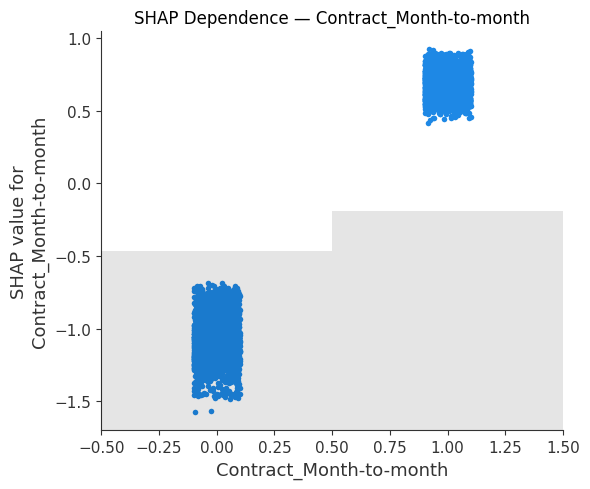

Saved: dependence_Contract_Month-to-month.png


In [6]:
# Get top feature
top_feature = mean_shap['Feature'].iloc[0]
print(f"Top churn driver: {top_feature}")

plt.figure()
shap.plots.scatter(shap_values[:, top_feature], show=False)
plt.title(f'SHAP Dependence — {top_feature}')
plt.tight_layout()
plt.savefig(f'../outputs/shap_plots/dependence_{top_feature}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: dependence_{top_feature}.png")

## Global SHAP Summary

Top churn drivers identified:
1. Contract type (Month-to-month = highest risk)
2. Tenure (shorter tenure = higher churn)
3. Monthly Charges (higher charges = more likely to churn)
4. Internet Service type
5. Number of support tickets / TechSupport

## Business Insight:
Customers on month-to-month contracts with short tenure and 
high monthly charges are the highest churn risk profile.
This directly informs our retention strategy in Module 3.

## Plots saved to outputs/shap_plots/
- global_feature_importance.png
- beeswarm_plot.png  
- top10_churn_drivers.png
- dependence_[top_feature].png